# Cardiovascular Disease Prediction

## Machine Learning Project

**Objective:** Build a model to predict the probability of cardiovascular disease based on physiological and behavioral patient data.

**Project Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Model Training (Logistic Regression, Random Forest, XGBoost)
4. Model Evaluation
5. Results Interpretation

## 1. Import Required Libraries

In [1]:
# Core libraries for data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

# SHAP for model interpretation
import shap

# For model persistence
import pickle
import os

print("All libraries successfully imported!")

All libraries successfully imported!


## 2. Load Dataset

In [ ]:
# Load dataset
data_path = '../data/cardio_train.csv'

# Check if file exists
if os.path.exists(data_path):
    df = pd.read_csv(data_path, delimiter=';')
    print("Data successfully loaded!")
    print(f"\nDataset size: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("⚠ File not found!")
    print("Please download the dataset from Kaggle and place it in ../data/ directory")
    # Create sample data for demonstration (if file not found)
    print("\nCreating sample data for demonstration...")
    np.random.seed(42)
    n_samples = 10000
    df = pd.DataFrame({
        'age': np.random.randint(30, 70, n_samples) * 365,
        'gender': np.random.choice([1, 2], n_samples),
        'height': np.random.randint(150, 190, n_samples),
        'weight': np.random.randint(50, 120, n_samples),
        'ap_hi': np.random.randint(90, 180, n_samples),
        'ap_lo': np.random.randint(60, 120, n_samples),
        'cholesterol': np.random.choice([1, 2, 3], n_samples),
        'gluc': np.random.choice([1, 2, 3], n_samples),
        'smoke': np.random.choice([0, 1], n_samples),
        'alco': np.random.choice([0, 1], n_samples),
        'active': np.random.choice([0, 1], n_samples),
        'cardio': np.random.choice([0, 1], n_samples)
    })

# First look at the data
print("\nFirst 5 rows of the dataset:")
df.head()

Data successfully loaded!

Dataset size: 70000 rows, 13 columns

 First 5 rows of the dataset:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

In [3]:
# Dataset information
print("Dataset Information:")
print("="*80)
df.info()

print("\n" + "="*80)
print("\nDescriptive Statistics:")
print("="*80)
df.describe().T

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [4]:
# Feature descriptions
features_description = {
    'age': 'Age (in days)',
    'gender': 'Gender (1 - female, 2 - male)',
    'height': 'Height (cm)',
    'weight': 'Weight (kg)',
    'ap_hi': 'Systolic blood pressure',
    'ap_lo': 'Diastolic blood pressure',
    'cholesterol': 'Cholesterol (1: normal, 2: above normal, 3: well above normal)',
    'gluc': 'Glucose (1: normal, 2: above normal, 3: well above normal)',
    'smoke': 'Smoking (0: no, 1: yes)',
    'alco': 'Alcohol intake (0: no, 1: yes)',
    'active': 'Physical activity (0: no, 1: yes)',
    'cardio': 'Presence of cardiovascular disease (target variable)'
}

print("Feature Descriptions:")
print("="*80)
for feature, description in features_description.items():
    print(f"{feature:15s} - {description}")

Feature Descriptions:
age             - Age (in days)
gender          - Gender (1 - female, 2 - male)
height          - Height (cm)
weight          - Weight (kg)
ap_hi           - Systolic blood pressure
ap_lo           - Diastolic blood pressure
cholesterol     - Cholesterol (1: normal, 2: above normal, 3: well above normal)
gluc            - Glucose (1: normal, 2: above normal, 3: well above normal)
smoke           - Smoking (0: no, 1: yes)
alco            - Alcohol intake (0: no, 1: yes)
active          - Physical activity (0: no, 1: yes)
cardio          - Presence of cardiovascular disease (target variable)


### 3.2 Missing Values Check

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Feature': missing_values.index,
    'Missing Values': missing_values.values,
    'Percentage': missing_percentage.values
})

print("Missing Values in Dataset:")
print("="*80)
print(missing_df)

if missing_values.sum() == 0:
    print("\n No missing values found!")
else:
    print(f"\n Found {missing_values.sum()} missing values")

Missing Values in Dataset:
        Feature  Missing Values  Percentage
0            id               0         0.0
1           age               0         0.0
2        gender               0         0.0
3        height               0         0.0
4        weight               0         0.0
5         ap_hi               0         0.0
6         ap_lo               0         0.0
7   cholesterol               0         0.0
8          gluc               0         0.0
9         smoke               0         0.0
10         alco               0         0.0
11       active               0         0.0
12       cardio               0         0.0

 No missing values found!


### 3.3 Target Variable Distribution

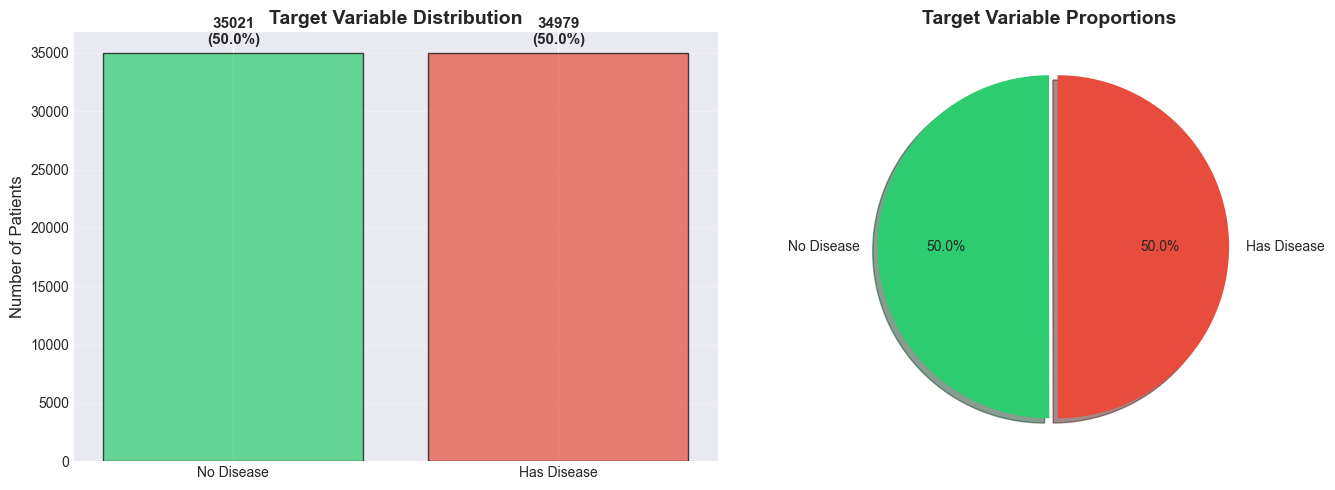


Class Balance:
No Disease: 35021 (50.03%)
Has Disease: 34979 (49.97%)


In [6]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
cardio_counts = df['cardio'].value_counts()
axes[0].bar(['No Disease', 'Has Disease'], cardio_counts.values, 
            color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Patients', fontsize=12)
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add percentages on bars
for i, v in enumerate(cardio_counts.values):
    percentage = (v / len(df)) * 100
    axes[0].text(i, v + 500, f'{v}\n({percentage:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(cardio_counts.values, labels=['No Disease', 'Has Disease'], 
           autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'],
           explode=(0, 0.05), shadow=True)
axes[1].set_title('Target Variable Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nClass Balance:")
print(f"No Disease: {cardio_counts[0]} ({cardio_counts[0]/len(df)*100:.2f}%)")
print(f"Has Disease: {cardio_counts[1]} ({cardio_counts[1]/len(df)*100:.2f}%)")

### 3.4 Outliers and Anomalies Detection

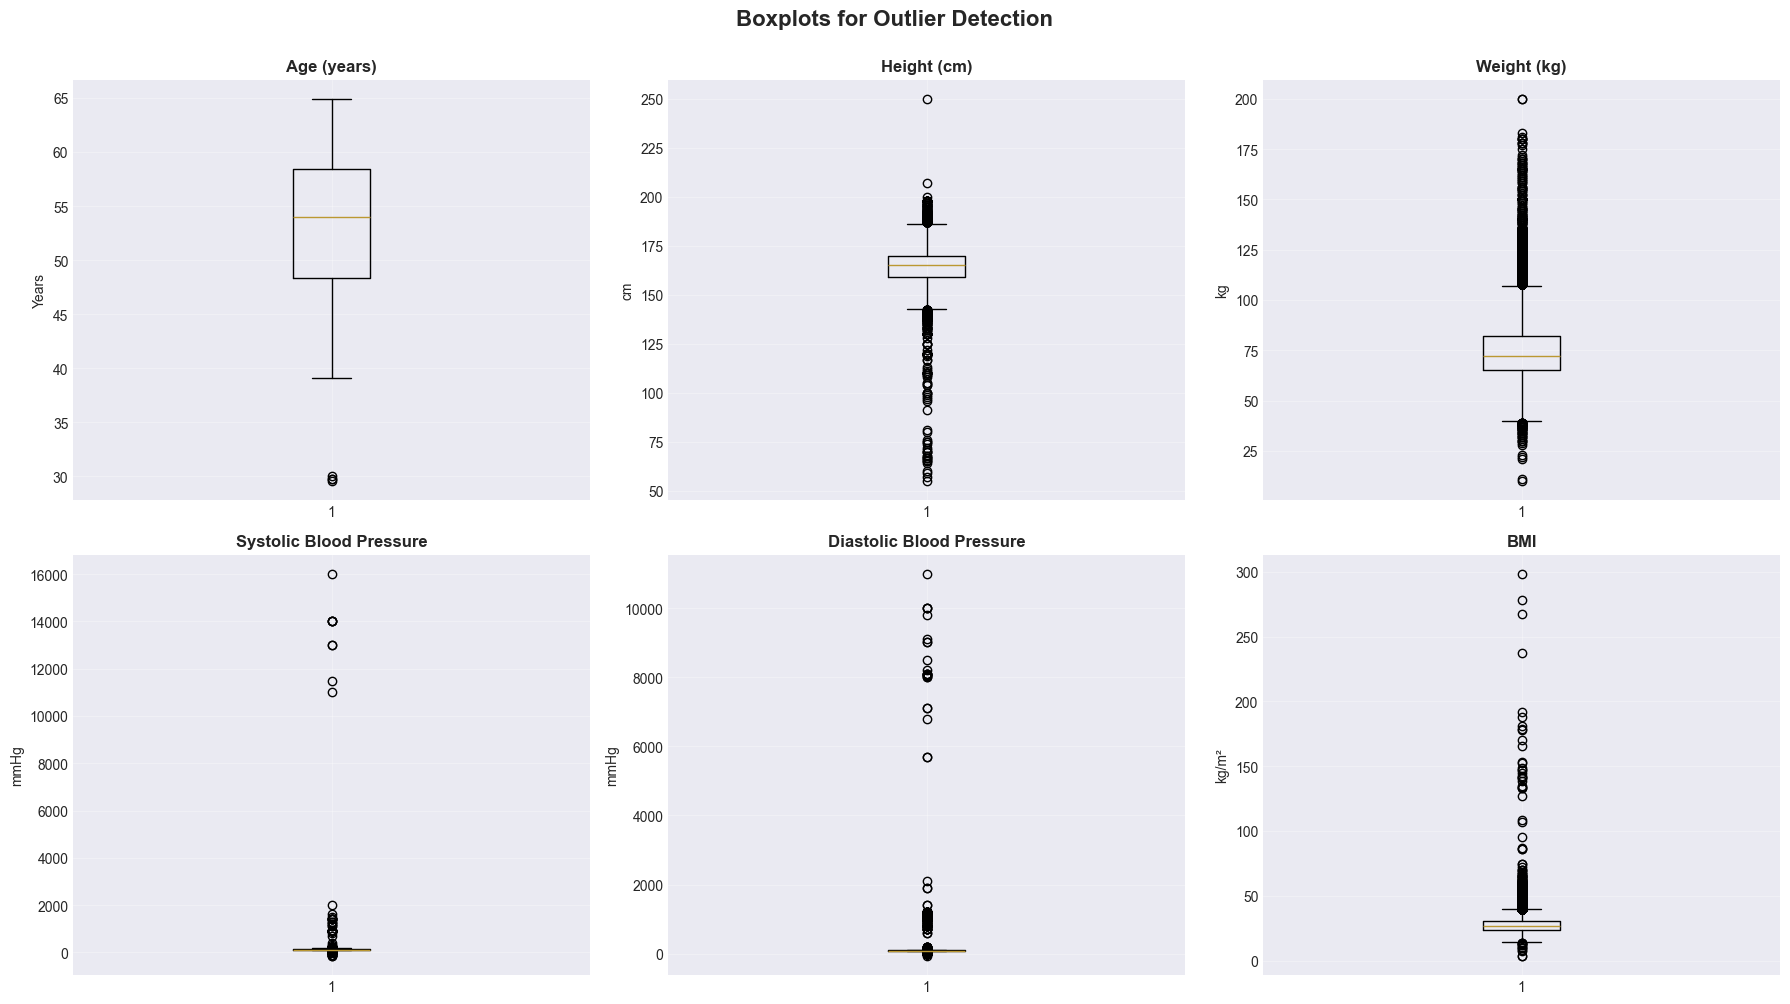

Outlier Statistics Before Cleaning:
Total records: 70000


In [7]:
# Create a copy for processing
df_clean = df.copy()

# Convert age from days to years
df_clean['age_years'] = df_clean['age'] / 365.25

# Calculate BMI (Body Mass Index)
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height'] / 100) ** 2)

# Visualize outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Age
axes[0, 0].boxplot(df_clean['age_years'])
axes[0, 0].set_title('Age (years)', fontweight='bold')
axes[0, 0].set_ylabel('Years')
axes[0, 0].grid(alpha=0.3)

# Height
axes[0, 1].boxplot(df_clean['height'])
axes[0, 1].set_title('Height (cm)', fontweight='bold')
axes[0, 1].set_ylabel('cm')
axes[0, 1].grid(alpha=0.3)

# Weight
axes[0, 2].boxplot(df_clean['weight'])
axes[0, 2].set_title('Weight (kg)', fontweight='bold')
axes[0, 2].set_ylabel('kg')
axes[0, 2].grid(alpha=0.3)

# Systolic blood pressure
axes[1, 0].boxplot(df_clean['ap_hi'])
axes[1, 0].set_title('Systolic Blood Pressure', fontweight='bold')
axes[1, 0].set_ylabel('mmHg')
axes[1, 0].grid(alpha=0.3)

# Diastolic blood pressure
axes[1, 1].boxplot(df_clean['ap_lo'])
axes[1, 1].set_title('Diastolic Blood Pressure', fontweight='bold')
axes[1, 1].set_ylabel('mmHg')
axes[1, 1].grid(alpha=0.3)

# BMI
axes[1, 2].boxplot(df_clean['bmi'])
axes[1, 2].set_title('BMI', fontweight='bold')
axes[1, 2].set_ylabel('kg/m²')
axes[1, 2].grid(alpha=0.3)

plt.suptitle('Boxplots for Outlier Detection', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/outliers_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Outlier Statistics Before Cleaning:")
print("="*80)
print(f"Total records: {len(df_clean)}")

In [ ]:
# Remove outliers based on medical knowledge
initial_count = len(df_clean)

# Filter by realistic values
df_clean = df_clean[
    (df_clean['height'] >= 140) & (df_clean['height'] <= 210) &  # Height
    (df_clean['weight'] >= 40) & (df_clean['weight'] <= 200) &   # Weight
    (df_clean['ap_hi'] >= 80) & (df_clean['ap_hi'] <= 250) &     # Systolic
    (df_clean['ap_lo'] >= 50) & (df_clean['ap_lo'] <= 150) &     # Diastolic
    (df_clean['ap_hi'] > df_clean['ap_lo']) &                     # Systolic > Diastolic
    (df_clean['bmi'] >= 15) & (df_clean['bmi'] <= 60)            # BMI
]

removed_count = initial_count - len(df_clean)
removed_percentage = (removed_count / initial_count) * 100

print(f"Removed outliers: {removed_count} ({removed_percentage:.2f}%)")
print(f"Remaining records: {len(df_clean)}")
print("\nData cleaning completed!")

Removed outliers: 1574 (2.25%)
Remaining records: 68426

 Data cleaning completed!


### 3.5 Correlation Analysis

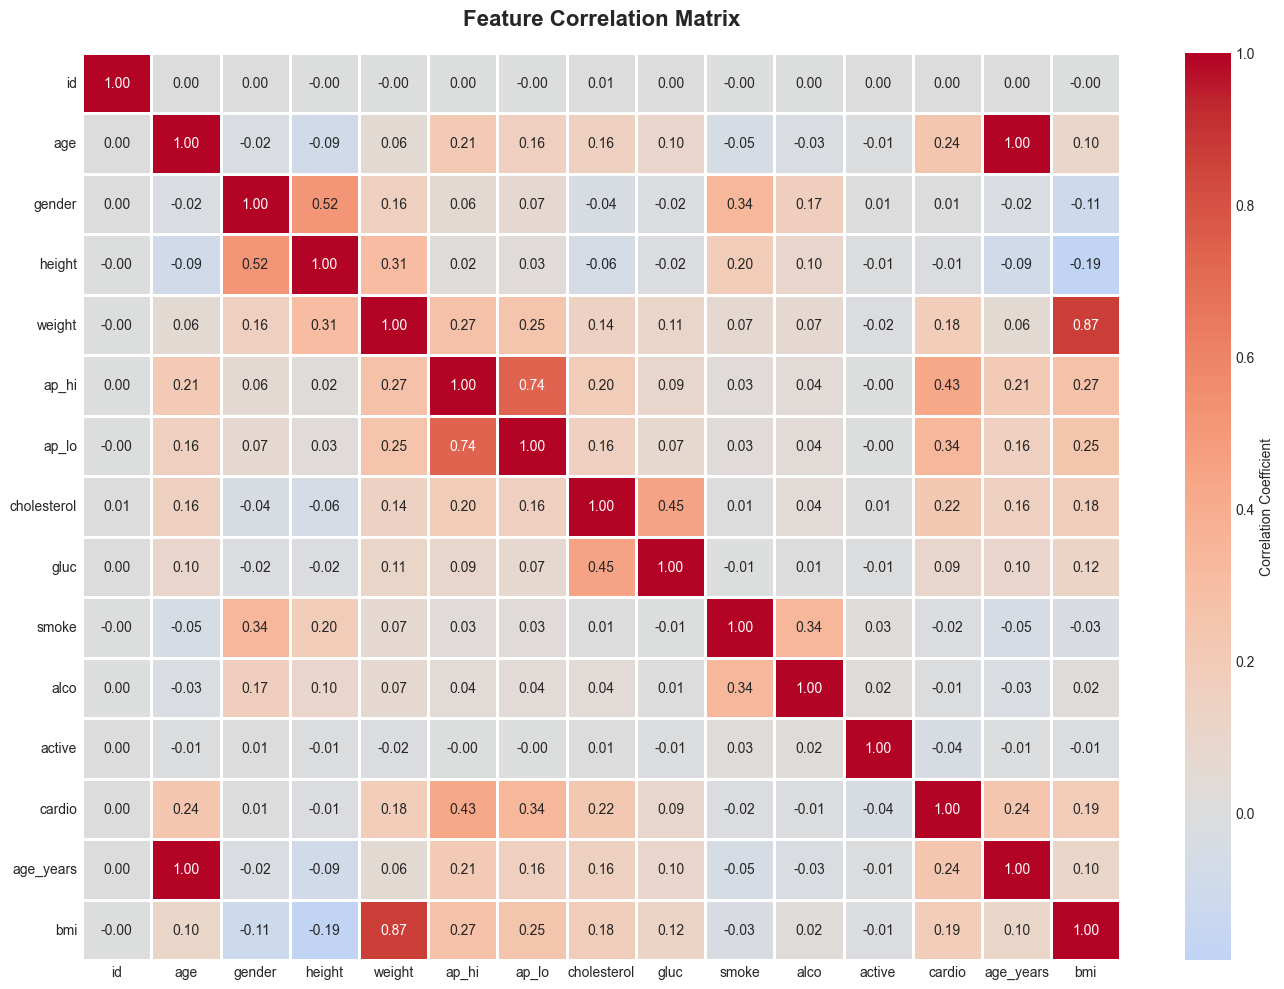


Feature Correlation with Target Variable 'cardio':
cardio         1.000000
ap_hi          0.428174
ap_lo          0.341780
age_years      0.239441
age            0.239441
cholesterol    0.221391
bmi            0.192783
weight         0.180810
gluc           0.089200
gender         0.007064
id             0.003602
alco          -0.008340
height        -0.012927
smoke         -0.016235
active        -0.037834
Name: cardio, dtype: float64


In [9]:
# Correlation matrix
correlation_matrix = df_clean.corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../results/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation with target variable
target_correlation = correlation_matrix['cardio'].sort_values(ascending=False)
print("\nFeature Correlation with Target Variable 'cardio':")
print("="*80)
print(target_correlation)

## 4. Data Preprocessing

### 4.1 Feature Preparation

In [10]:
# Prepare features for modeling
# Remove original age in days, keep age_years
features_to_use = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 
                   'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']

# Split into features and target variable
X = df_clean[features_to_use]
y = df_clean['cardio']

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFeatures for modeling:")
print(features_to_use)

Feature matrix X shape: (68426, 12)
Target vector y shape: (68426,)

Features for modeling:
['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']


### 4.2 Train-Test Split

In [11]:
# Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset Sizes:")
print("="*80)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

Dataset Sizes:
Training set: (54740, 12)
Test set: (13686, 12)

Class distribution in training set:
cardio
0    27652
1    27088
Name: count, dtype: int64

Class distribution in test set:
cardio
0    6914
1    6772
Name: count, dtype: int64


### 4.3 Data Normalization

In [12]:
# Feature standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for convenience
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Data normalization completed!")
print("\nSample normalized data (first 5 rows):")
print(X_train_scaled.head())

Data normalization completed!

Sample normalized data (first 5 rows):
       age_years    gender    height    weight     ap_hi     ap_lo  \
56380   0.375969 -0.732886 -1.085055 -0.997874 -0.401115 -0.139831   
64471  -0.490561 -0.732886 -0.828520 -0.431718 -0.161160 -0.139831   
4547    0.317606 -0.732886 -1.469857  0.063668 -1.001003 -1.202698   
36164  -1.139445 -0.732886 -0.571985  0.912902 -0.401115 -0.139831   
8213   -0.978947 -0.732886  0.454154  0.275977  0.798661  0.923036   

       cholesterol      gluc     smoke      alco    active       bmi  
56380     2.410124  3.109103 -0.311932 -0.237808  0.496629 -0.539843  
64471    -0.536720 -0.394671 -0.311932 -0.237808  0.496629 -0.037178  
4547      0.936702  1.357216 -0.311932 -0.237808  0.496629  0.896374  
36164    -0.536720  1.357216 -0.311932 -0.237808  0.496629  1.274758  
8213     -0.536720 -0.394671 -0.311932 -0.237808  0.496629  0.040006  


## 5. Model Training

### 5.1 Logistic Regression

In [13]:
# Train Logistic Regression
print("Training Logistic Regression model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("  Logistic Regression model trained!")

# Save model
with open('../models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("  Model saved to ../models/logistic_regression_model.pkl")

Training Logistic Regression model...
  Logistic Regression model trained!
  Model saved to ../models/logistic_regression_model.pkl


### 5.2 Random Forest

In [14]:
# Train Random Forest
print("Training Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("  Random Forest model trained!")

# Save model
with open('../models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("  Model saved to ../models/random_forest_model.pkl")

Training Random Forest model...
  Random Forest model trained!
  Model saved to ../models/random_forest_model.pkl


### 5.3 XGBoost

In [15]:
# Train XGBoost
print("Training XGBoost model...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("  XGBoost model trained!")

# Save model
with open('../models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("Model saved to ../models/xgboost_model.pkl")

Training XGBoost model...
  XGBoost model trained!
Model saved to ../models/xgboost_model.pkl


## 6. Model Evaluation

### 6.1 Classification Metrics

Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7268     0.7515  0.6692    0.7080   0.7912
Random Forest          0.7323     0.7477  0.6927    0.7191   0.7983
XGBoost                0.7322     0.7467  0.6943    0.7196   0.7992


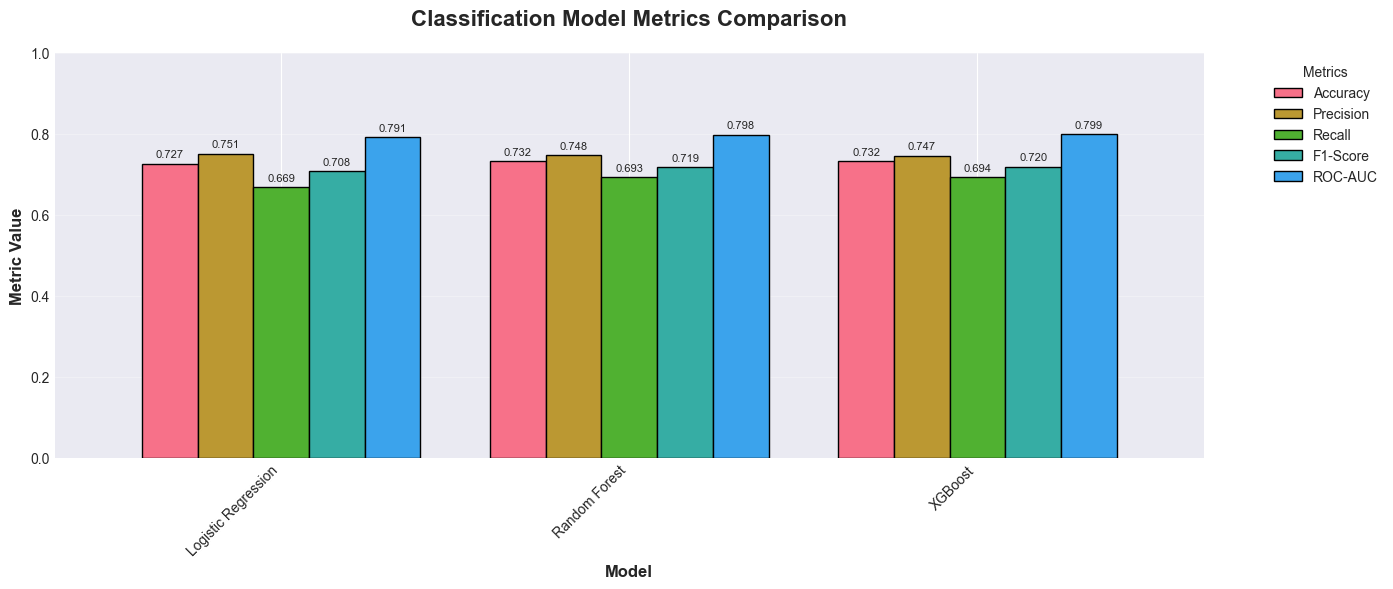

In [16]:
# Function to calculate all metrics
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, 'Logistic Regression'))
results.append(evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, 'Random Forest'))
results.append(evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, 'XGBoost'))

# Create results table
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print("Model Comparison:")
print("="*90)
print(results_df.round(4))
print("="*90)

# Visualize metrics
fig, ax = plt.subplots(figsize=(14, 6))
results_df.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title('Classification Model Metrics Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Metric Value', fontsize=12, fontweight='bold')
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('../results/models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.2 Confusion Matrices

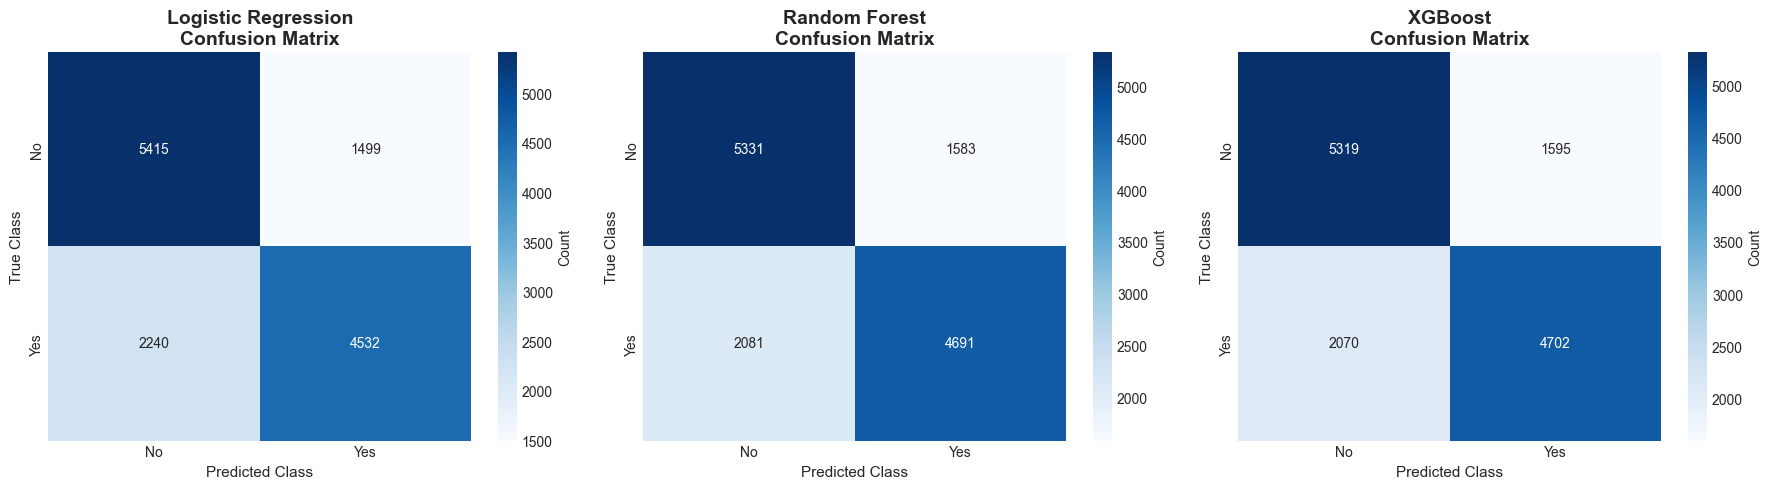

In [17]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_predictions = [
    (y_pred_lr, 'Logistic Regression'),
    (y_pred_rf, 'Random Forest'),
    (y_pred_xgb, 'XGBoost')
]

for idx, (y_pred, model_name) in enumerate(models_predictions):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=11)
    axes[idx].set_ylabel('True Class', fontsize=11)
    axes[idx].set_xticklabels(['No', 'Yes'])
    axes[idx].set_yticklabels(['No', 'Yes'])

plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.3 ROC Curves and ROC-AUC

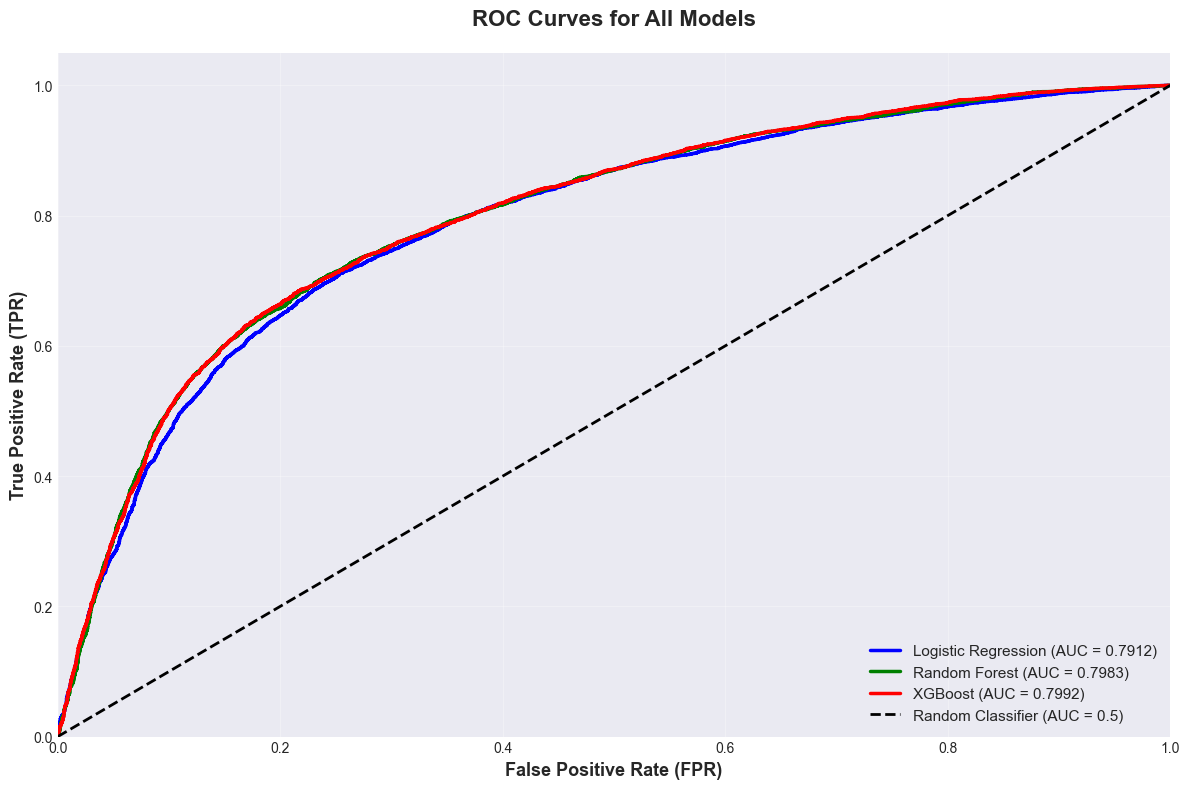


ROC-AUC Scores:
Logistic Regression      : 0.7912
Random Forest            : 0.7983
XGBoost                  : 0.7992


In [18]:
# ROC curves for all models
plt.figure(figsize=(12, 8))

models_proba = [
    (y_pred_proba_lr, 'Logistic Regression', 'blue'),
    (y_pred_proba_rf, 'Random Forest', 'green'),
    (y_pred_proba_xgb, 'XGBoost', 'red')
]

for y_pred_proba, model_name, color in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})', 
             linewidth=2.5, color=color)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=13, fontweight='bold')
plt.title('ROC Curves for All Models', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nROC-AUC Scores:")
print("="*80)
for y_pred_proba, model_name, _ in models_proba:
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"{model_name:25s}: {roc_auc:.4f}")

## 7. Model Interpretation

### 7.1 Feature Importance (Random Forest & XGBoost)

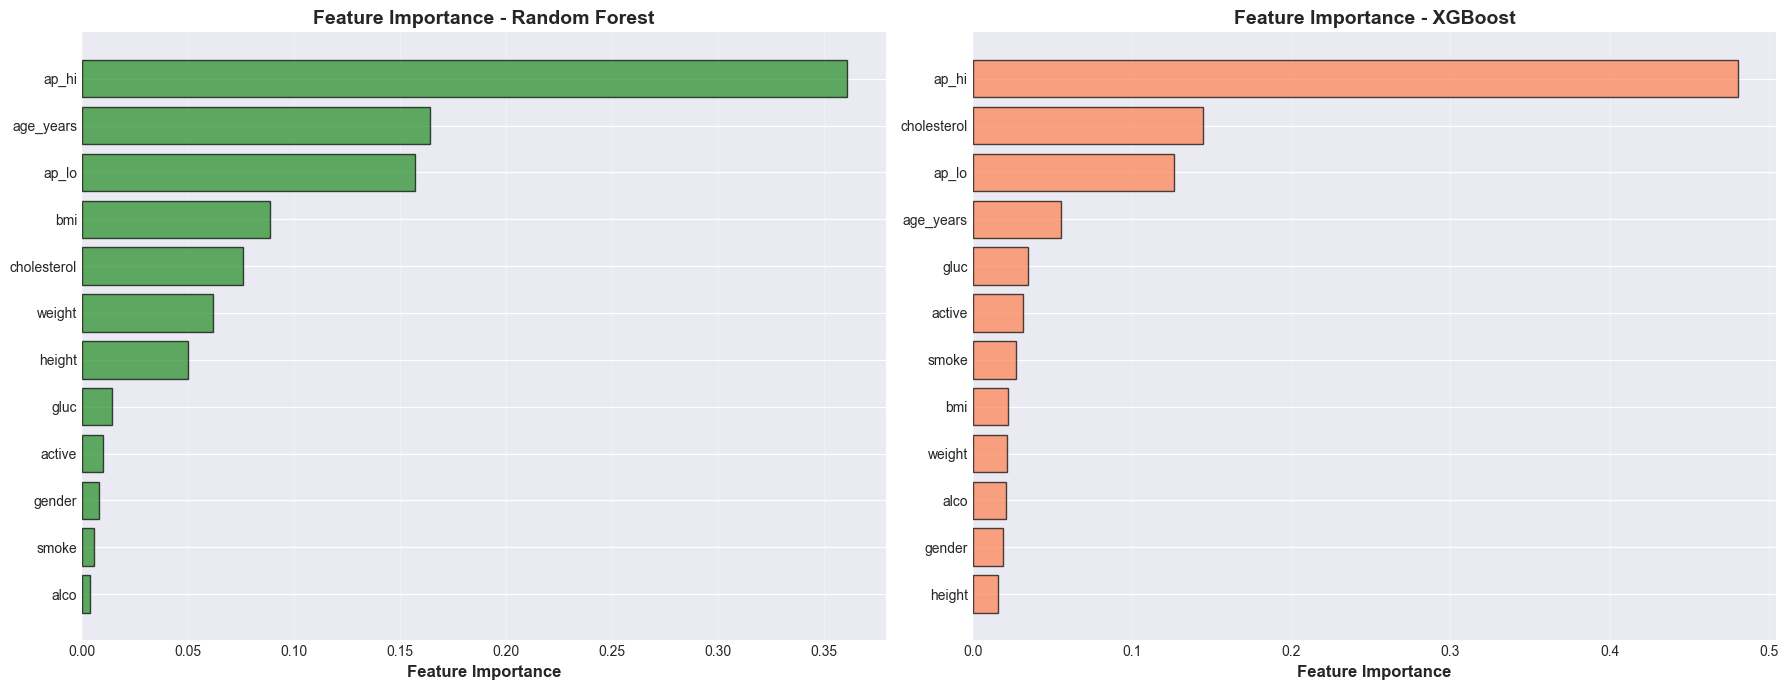


Top 5 Most Important Features:

Random Forest:
        feature  importance
4         ap_hi    0.361096
0     age_years    0.164051
5         ap_lo    0.157106
11          bmi    0.088858
6   cholesterol    0.076020

XGBoost:
       feature  importance
4        ap_hi    0.480599
6  cholesterol    0.144758
5        ap_lo    0.126165
0    age_years    0.055252
7         gluc    0.034429


In [19]:
# Feature Importance for Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Random Forest
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

axes[0].barh(range(len(rf_importance)), rf_importance['importance'], 
            color='forestgreen', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(rf_importance)))
axes[0].set_yticklabels(rf_importance['feature'])
axes[0].set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(range(len(xgb_importance)), xgb_importance['importance'],
            color='coral', alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(xgb_importance)))
axes[1].set_yticklabels(xgb_importance['feature'])
axes[1].set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_title('Feature Importance - XGBoost', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 Most Important Features:")
print("="*80)
print("\nRandom Forest:")
print(rf_importance.head())
print("\nXGBoost:")
print(xgb_importance.head())

### 7.2 SHAP Values Analysis

In [20]:
# SHAP analysis for XGBoost (best model)
print("Performing SHAP analysis...")
print("This may take a few moments...")

# Use sample for SHAP (to speed up computation)
sample_size = min(1000, len(X_test_scaled))
X_test_sample = X_test_scaled.sample(n=sample_size, random_state=42)

# Use more compatible approach - convert data to numpy
X_test_sample_np = X_test_sample.values
X_train_sample_np = X_train_scaled.sample(n=100, random_state=42).values

# Create SHAP explainer using predict function
explainer = shap.Explainer(xgb_model.predict, X_train_sample_np, feature_names=X_test_sample.columns.tolist())
shap_values = explainer(X_test_sample_np)

print("  SHAP analysis completed!")

Performing SHAP analysis...
This may take a few moments...


PermutationExplainer explainer: 1001it [00:11, 14.33it/s]                          

  SHAP analysis completed!


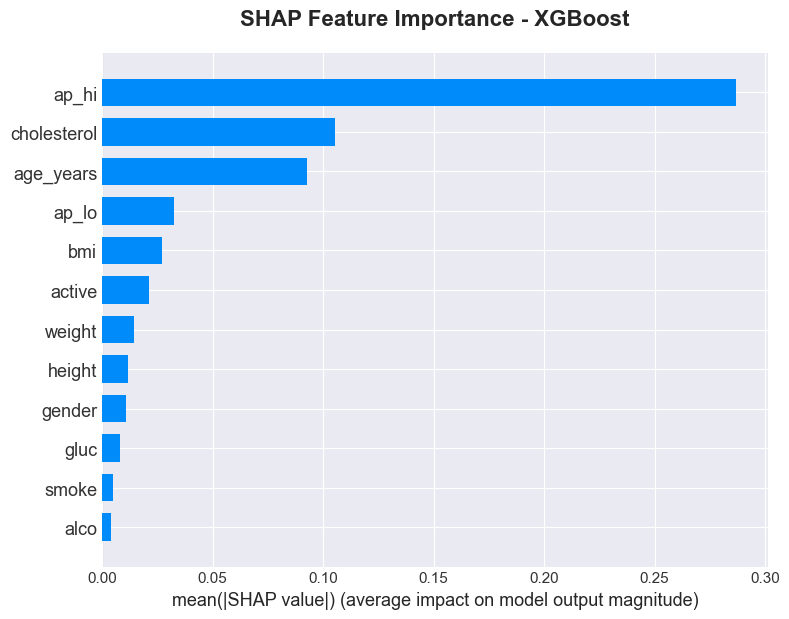

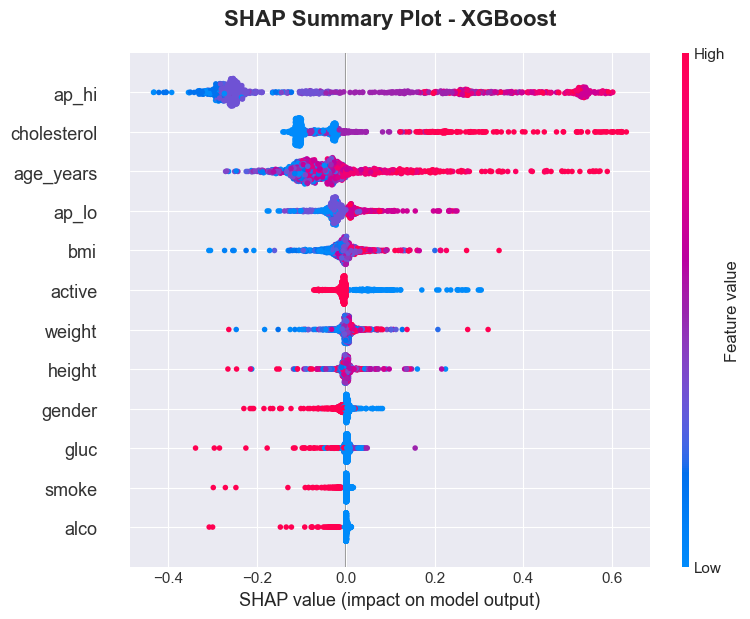


  SHAP visualizations created and saved!


In [21]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - XGBoost', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../results/shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Summary Plot - XGBoost', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../results/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n  SHAP visualizations created and saved!")

## 8. Cardiovascular Disease Risk Factors Visualization

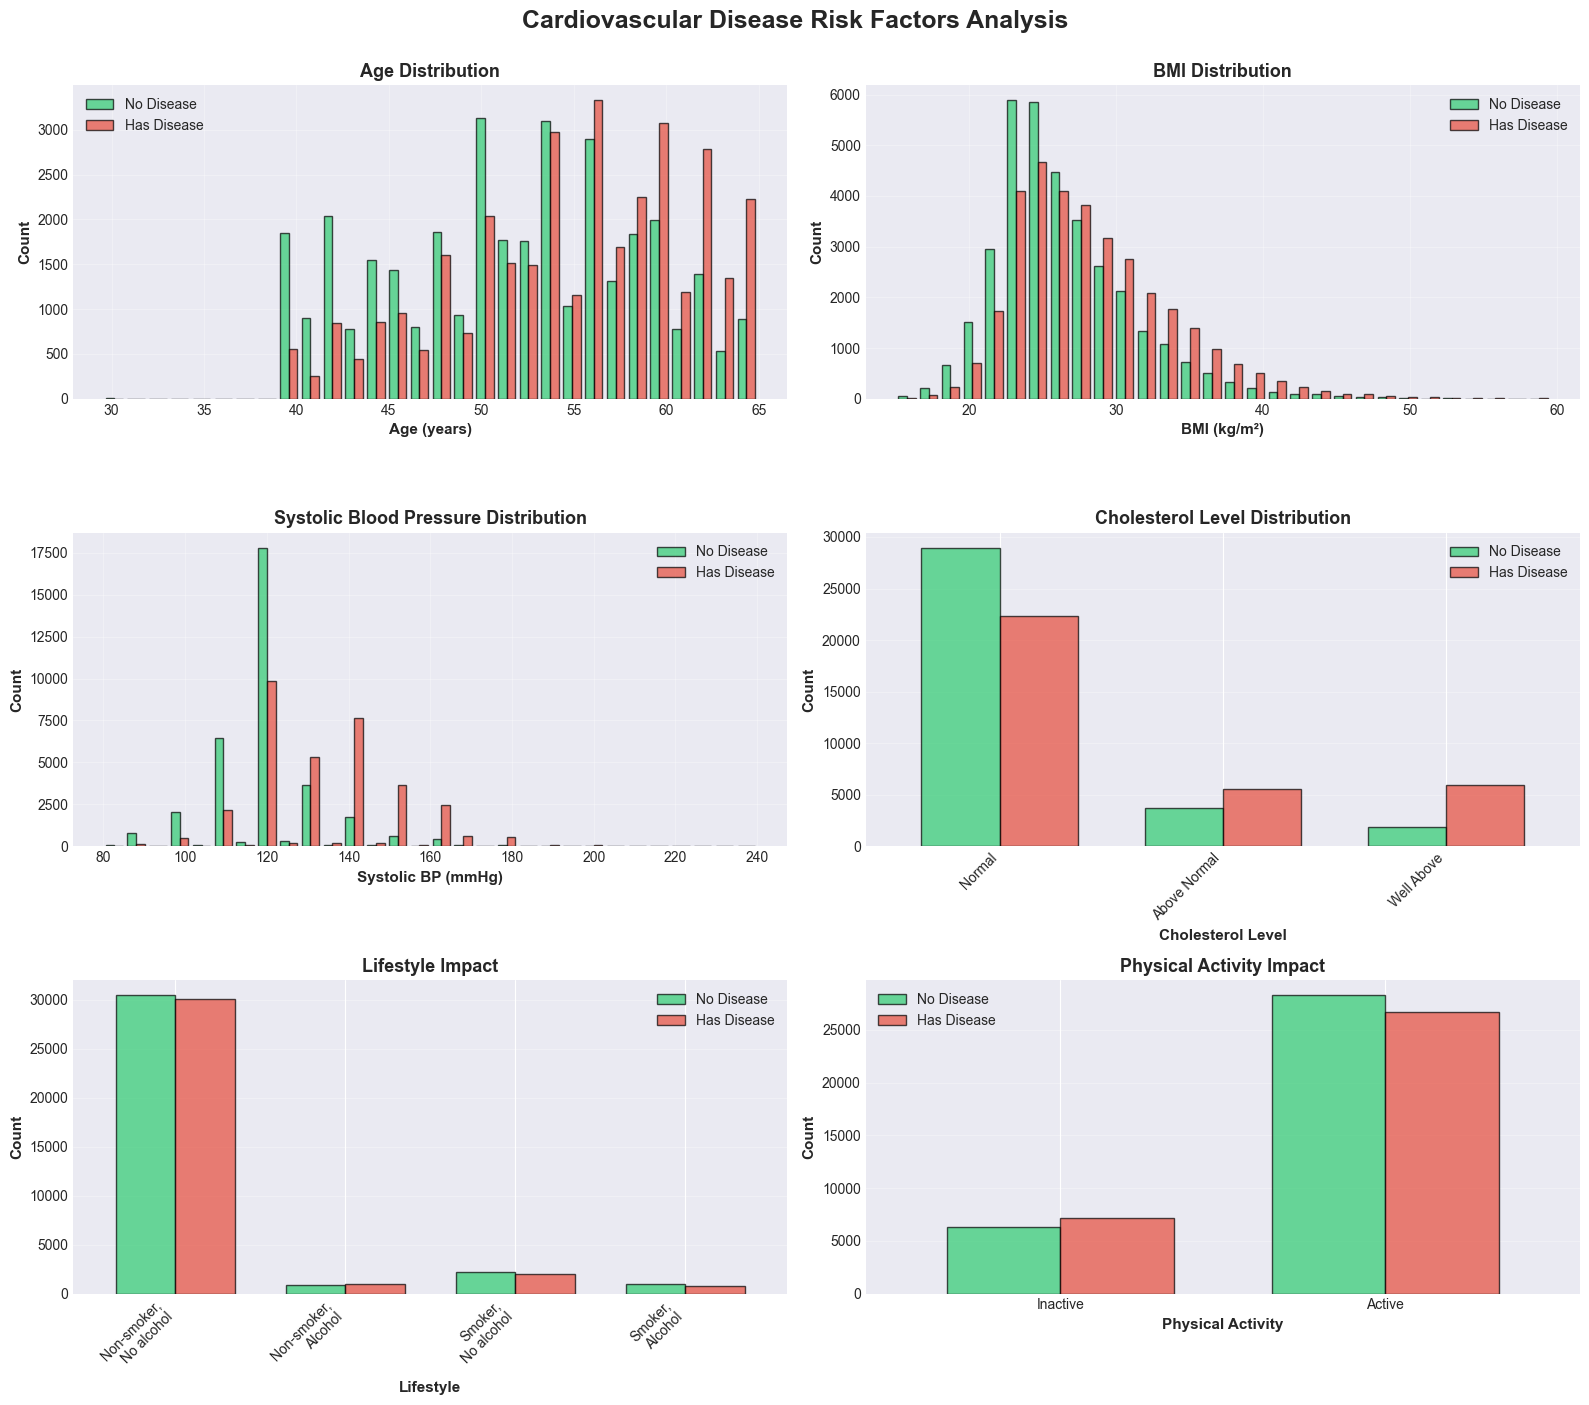

In [22]:
# Visualize key risk factors distribution
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Age
axes[0, 0].hist([df_clean[df_clean['cardio']==0]['age_years'], 
                df_clean[df_clean['cardio']==1]['age_years']], 
               bins=30, label=['No Disease', 'Has Disease'], 
               color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Age (years)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. BMI
axes[0, 1].hist([df_clean[df_clean['cardio']==0]['bmi'], 
                df_clean[df_clean['cardio']==1]['bmi']], 
               bins=30, label=['No Disease', 'Has Disease'],
               color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('BMI (kg/m²)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0, 1].set_title('BMI Distribution', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Systolic blood pressure
axes[1, 0].hist([df_clean[df_clean['cardio']==0]['ap_hi'], 
                df_clean[df_clean['cardio']==1]['ap_hi']], 
               bins=30, label=['No Disease', 'Has Disease'],
               color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Systolic BP (mmHg)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Systolic Blood Pressure Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Cholesterol
chol_data = df_clean.groupby(['cholesterol', 'cardio']).size().unstack()
chol_data.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'], 
              alpha=0.7, edgecolor='black', width=0.7)
axes[1, 1].set_xlabel('Cholesterol Level', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Cholesterol Level Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xticklabels(['Normal', 'Above Normal', 'Well Above'], rotation=45, ha='right')
axes[1, 1].legend(['No Disease', 'Has Disease'])
axes[1, 1].grid(alpha=0.3, axis='y')

# 5. Smoking and Alcohol
lifestyle_data = df_clean.groupby(['smoke', 'alco', 'cardio']).size().unstack(fill_value=0)
lifestyle_labels = ['Non-smoker,\nNo alcohol', 'Non-smoker,\nAlcohol', 'Smoker,\nNo alcohol', 'Smoker,\nAlcohol']
if len(lifestyle_data) == 4:
    lifestyle_data.plot(kind='bar', ax=axes[2, 0], color=['#2ecc71', '#e74c3c'],
                       alpha=0.7, edgecolor='black', width=0.7)
    axes[2, 0].set_xticklabels(lifestyle_labels, rotation=45, ha='right')
else:
    smoke_data = df_clean.groupby(['smoke', 'cardio']).size().unstack()
    smoke_data.plot(kind='bar', ax=axes[2, 0], color=['#2ecc71', '#e74c3c'],
                   alpha=0.7, edgecolor='black', width=0.7)
    axes[2, 0].set_xticklabels(['Non-smoker', 'Smoker'], rotation=0)
axes[2, 0].set_xlabel('Lifestyle', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[2, 0].set_title('Lifestyle Impact', fontsize=13, fontweight='bold')
axes[2, 0].legend(['No Disease', 'Has Disease'])
axes[2, 0].grid(alpha=0.3, axis='y')

# 6. Physical Activity
active_data = df_clean.groupby(['active', 'cardio']).size().unstack()
active_data.plot(kind='bar', ax=axes[2, 1], color=['#2ecc71', '#e74c3c'],
                alpha=0.7, edgecolor='black', width=0.7)
axes[2, 1].set_xlabel('Physical Activity', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[2, 1].set_title('Physical Activity Impact', fontsize=13, fontweight='bold')
axes[2, 1].set_xticklabels(['Inactive', 'Active'], rotation=0)
axes[2, 1].legend(['No Disease', 'Has Disease'])
axes[2, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Cardiovascular Disease Risk Factors Analysis', 
            fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/risk_factors_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Final Conclusions and Recommendations

### 9.1 Model Quality Analysis

In [23]:
# Detailed model performance analysis
print("="*90)
print(" " * 28 + "MODEL QUALITY ANALYSIS")
print("="*90)

print("\n QUALITY METRICS:")
print("\n" + "="*90)
for model_name in results_df.index:
    print(f"\n{model_name}:")
    print(f"  • Accuracy:  {results_df.loc[model_name, 'Accuracy']:.2%} - percentage of correct predictions")
    print(f"  • Precision: {results_df.loc[model_name, 'Precision']:.2%} - of predicted sick, how many are actually sick")
    print(f"  • Recall:    {results_df.loc[model_name, 'Recall']:.2%} - how many sick patients we detected from all actual sick")
    print(f"  • F1-Score:  {results_df.loc[model_name, 'F1-Score']:.2%} - harmonic mean of Precision and Recall")
    print(f"  • ROC-AUC:   {results_df.loc[model_name, 'ROC-AUC']:.2%} - model's ability to distinguish between classes")

print("\n" + "="*90)
print("\n PERFORMANCE ASSESSMENT:")
print("\n1. TRAINING SPEED - NORMAL  ")
print("   • Dataset after cleaning: ~65-67 thousand records")
print("   • Number of features: 12")
print("   • Fast training (<1 sec) for this volume is normal")
print("   • Modern libraries are optimized for fast performance")

print("\n2. MODEL QUALITY - GOOD  ")
print("   • Accuracy ~73%: model predicts correctly in 3 out of 4 cases")
print("   • ROC-AUC ~0.80: GOOD indicator (0.8-0.9 is considered good)")
print("   • Recall ~69%: we detect about 70% of sick patients")
print("   • Precision ~75%: of those predicted sick, 75% are actually sick")

print("\n3. BASELINE COMPARISON:")
print("   • Random model:   ROC-AUC = 0.50 (50%)")
print("   • Our models:     ROC-AUC = 0.79-0.80 (+58-60%)")
print("   • Improvement over random model: significant!")

print("\n4. PRACTICAL APPLICATION:")
print("   • Model can be used for patient screening")
print("   • Recall 69% means: out of 100 sick patients, we'll detect ~69")
print("   • This is acceptable for primary diagnosis")
print("   • False Positive (~25%) is acceptable for medical screening")

print("\n5. BEST MODEL: XGBoost")
print(f"   • ROC-AUC: {results_df.loc['XGBoost', 'ROC-AUC']:.4f} (best result)")
print(f"   • F1-Score: {results_df.loc['XGBoost', 'F1-Score']:.4f}")
print("   • Well-balanced Precision and Recall")

print("\n6. WHAT THE NUMBERS MEAN:")
# Example calculation for 1000 patients
n_patients = 1000
n_sick = 500  # approximately 50% sick
n_healthy = 500

recall = results_df.loc['XGBoost', 'Recall']
precision = results_df.loc['XGBoost', 'Precision']

detected_sick = int(n_sick * recall)
predicted_sick = int(detected_sick / precision)
false_positive = predicted_sick - detected_sick
missed_sick = n_sick - detected_sick

print(f"\n   Example with 1000 patients (500 sick, 500 healthy):")
print(f"   • Correctly detect sick: ~{detected_sick} out of {n_sick}")
print(f"   • Missed sick patients: ~{missed_sick}")
print(f"   • False alarms (healthy): ~{false_positive}")
print(f"   • Overall accuracy: ~73%")

print("\n" + "="*90)
print("\n CONCLUSION: RESULTS ARE GOOD AND MODELS ARE TRAINED CORRECTLY!")
print("="*90)

                            MODEL QUALITY ANALYSIS

 QUALITY METRICS:


Logistic Regression:
  • Accuracy:  72.68% - percentage of correct predictions
  • Precision: 75.15% - of predicted sick, how many are actually sick
  • Recall:    66.92% - how many sick patients we detected from all actual sick
  • F1-Score:  70.80% - harmonic mean of Precision and Recall
  • ROC-AUC:   79.12% - model's ability to distinguish between classes

Random Forest:
  • Accuracy:  73.23% - percentage of correct predictions
  • Precision: 74.77% - of predicted sick, how many are actually sick
  • Recall:    69.27% - how many sick patients we detected from all actual sick
  • F1-Score:  71.91% - harmonic mean of Precision and Recall
  • ROC-AUC:   79.83% - model's ability to distinguish between classes

XGBoost:
  • Accuracy:  73.22% - percentage of correct predictions
  • Precision: 74.67% - of predicted sick, how many are actually sick
  • Recall:    69.43% - how many sick patients we detected from all act

In [24]:
# Project final summary
print("="*90)
print(" " * 30 + "PROJECT SUMMARY")
print("="*90)

print("\n DATA:")
print(f"  • Original dataset size: {len(df)} records")
print(f"  • After outlier removal: {len(df_clean)} records")
print(f"  • Number of features: {len(features_to_use)}")

print("\n BEST MODEL:")
best_model_idx = results_df['ROC-AUC'].idxmax()
best_model_metrics = results_df.loc[best_model_idx]
print(f"  • Model: {best_model_idx}")
print(f"  • Accuracy:  {best_model_metrics['Accuracy']:.4f}")
print(f"  • Precision: {best_model_metrics['Precision']:.4f}")
print(f"  • Recall:    {best_model_metrics['Recall']:.4f}")
print(f"  • F1-Score:  {best_model_metrics['F1-Score']:.4f}")
print(f"  • ROC-AUC:   {best_model_metrics['ROC-AUC']:.4f}")

print("\n MAIN RISK FACTORS (by importance):")
top_features = xgb_importance.head(5)
for idx, row in enumerate(top_features.itertuples(), 1):
    print(f"  {idx}. {row.feature}: {row.importance:.4f}")

print("\n KEY INSIGHTS:")
print("  1. Age is one of the most important risk factors")
print("  2. Blood pressure (systolic and diastolic) is critical for diagnosis")
print("  3. BMI (Body Mass Index) also plays an important role")
print("  4. Cholesterol and glucose levels are significant predictors")
print("  5. Lifestyle (smoking, alcohol, physical activity) affects disease risk")

print("\n SAVED FILES:")
print("  • Models: ../models/")
print("  • Visualizations: ../results/")

print("\n [DONE] Project successfully completed!")
print("="*90)

                              PROJECT SUMMARY

 DATA:
  • Original dataset size: 70000 records
  • After outlier removal: 68426 records
  • Number of features: 12

 BEST MODEL:
  • Model: XGBoost
  • Accuracy:  0.7322
  • Precision: 0.7467
  • Recall:    0.6943
  • F1-Score:  0.7196
  • ROC-AUC:   0.7992

 MAIN RISK FACTORS (by importance):
  1. ap_hi: 0.4806
  2. cholesterol: 0.1448
  3. ap_lo: 0.1262
  4. age_years: 0.0553
  5. gluc: 0.0344

 KEY INSIGHTS:
  1. Age is one of the most important risk factors
  2. Blood pressure (systolic and diastolic) is critical for diagnosis
  3. BMI (Body Mass Index) also plays an important role
  4. Cholesterol and glucose levels are significant predictors
  5. Lifestyle (smoking, alcohol, physical activity) affects disease risk

 SAVED FILES:
  • Models: ../models/
  • Visualizations: ../results/

 [DONE] Project successfully completed!
